In [77]:
from abc import ABC, abstractmethod
from dataclasses import dataclass
from typing import Annotated

import random

import numpy as np
from numpy.lib.stride_tricks import as_strided

from geneticengine.grammar.metahandlers.ints import IntRange
from geneticengine.grammar import extract_grammar
from geneticengine.problems import SingleObjectiveProblem, MultiObjectiveProblem
from geneticengine.random.sources import NativeRandomSource
from geneticengine.algorithms.gp.gp import GeneticProgramming
from geneticengine.evaluation.budget import TimeBudget, EvaluationBudget
from geneticengine.representations.tree.initializations import MaxDepthDecider, FullDecider, ProgressivelyTerminalDecider, PositionIndependentGrowDecider
from geneticengine.representations.tree.operators import GrowInitializer, PositionIndependentGrowInitializer, FullInitializer, RampedHalfAndHalfInitializer
from geneticengine.algorithms.gp.operators.initializers import HalfAndHalfInitializer, StandardInitializer
from geneticengine.representations.tree.treebased import TreeBasedRepresentation
from geneticengine.representations.grammatical_evolution.structured_ge import StructuredGrammaticalEvolutionRepresentation
from geneticengine.evaluation.recorder import CSVSearchRecorder
from geneticengine.evaluation.tracker import ProgressTracker
from geneticengine.evaluation.parallel import ParallelEvaluator

from geneticengine.algorithms.gp.operators.combinators import ParallelStep, SequenceStep
from geneticengine.algorithms.gp.operators.crossover import GenericCrossoverStep
from geneticengine.algorithms.gp.operators.elitism import ElitismStep
from geneticengine.algorithms.gp.operators.mutation import GenericMutationStep
from geneticengine.algorithms.gp.operators.novelty import NoveltyStep
from geneticengine.algorithms.gp.operators.selection import LexicaseSelection, TournamentSelection

from sklearn.datasets import load_breast_cancer

import pandas as pd

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import f1_score, confusion_matrix, classification_report, ConfusionMatrixDisplay, roc_auc_score, roc_curve, auc
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

import time

import seaborn as sns
import matplotlib.pyplot as plt

In [78]:
def plot_roc(fpr, tpr):
    plt.plot(fpr, tpr, label='ROC curve')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC curve')
    plt.legend()
    plt.show()

def evaluate(predictions, FIXED_FPR = 0.05):
    fprs, tprs, thresholds = roc_curve(y_test, predictions)
    plot_roc(fprs, tprs)
    tpr = tprs[fprs<FIXED_FPR][-1]
    fpr = fprs[fprs<FIXED_FPR][-1]
    threshold = thresholds[fprs<FIXED_FPR][-1]
        
    print("AUC:", roc_auc_score(y_test, predictions))
    to_pct = lambda x: str(round(x, 4) * 100) + "%"
    print("TPR: ", to_pct(tpr), "\nFPR: ", to_pct(fpr), "\nThreshold: ", round(threshold, 2))

In [79]:
df = pd.read_csv('base.csv')

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 32 columns):
 #   Column                            Non-Null Count    Dtype  
---  ------                            --------------    -----  
 0   fraud_bool                        1000000 non-null  int64  
 1   income                            1000000 non-null  float64
 2   name_email_similarity             1000000 non-null  float64
 3   prev_address_months_count         1000000 non-null  int64  
 4   current_address_months_count      1000000 non-null  int64  
 5   customer_age                      1000000 non-null  int64  
 6   days_since_request                1000000 non-null  float64
 7   intended_balcon_amount            1000000 non-null  float64
 8   payment_type                      1000000 non-null  object 
 9   zip_count_4w                      1000000 non-null  int64  
 10  velocity_6h                       1000000 non-null  float64
 11  velocity_24h                      1000

In [80]:
df.head(2)

,fraud_bool,income,name_email_similarity,prev_address_months_count,current_address_months_count,customer_age,days_since_request,intended_balcon_amount,payment_type,zip_count_4w,...,has_other_cards,proposed_credit_limit,foreign_request,source,session_length_in_minutes,device_os,keep_alive_session,device_distinct_emails_8w,device_fraud_count,month
0,0,0.3,0.986506,-1,25,40,0.006735,102.453711,AA,1059,...,0,1500.0,0,INTERNET,16.224843,linux,1,1,0,0
1,0,0.8,0.617426,-1,89,20,0.010095,-0.849551,AD,1658,...,0,1500.0,0,INTERNET,3.363854,other,1,1,0,0


In [81]:
categorical_features = [col for col in df.columns if df[col].dtype == 'object']

encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

encoded_data = encoder.fit_transform(df[categorical_features])

encoded_df = pd.DataFrame(encoded_data, columns=encoder.get_feature_names_out(categorical_features))

df = df.drop(columns=categorical_features).reset_index(drop=True)
df = pd.concat([df, encoded_df], axis=1)

df.head(2)

,fraud_bool,income,name_email_similarity,prev_address_months_count,current_address_months_count,customer_age,days_since_request,intended_balcon_amount,zip_count_4w,velocity_6h,...,housing_status_BE,housing_status_BF,housing_status_BG,source_INTERNET,source_TELEAPP,device_os_linux,device_os_macintosh,device_os_other,device_os_windows,device_os_x11
0,0,0.3,0.986506,-1,25,40,0.006735,102.453711,1059,13096.035018,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0
1,0,0.8,0.617426,-1,89,20,0.010095,-0.849551,1658,9223.283431,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0


In [82]:
df['month'].value_counts().sort_index()

month
0    132440
1    127620
2    136979
3    150936
4    127691
5    119323
6    108168
7     96843
Name: count, dtype: int64

In [83]:
X = df.drop(['fraud_bool'], axis=1)
y = df['fraud_bool']

X_train = X[X['month']<6]
X_test = X[X['month']>=6]
y_train = y[X['month']<6]
y_test = y[X['month']>=6]

X_train.drop('month', axis=1, inplace=True)
X_test.drop('month', axis=1, inplace=True)

C:\Users\Gabriel\AppData\Local\Temp\ipykernel_25648\593396559.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_train.drop('month', axis=1, inplace=True)
C:\Users\Gabriel\AppData\Local\Temp\ipykernel_25648\593396559.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_test.drop('month', axis=1, inplace=True)


In [84]:
feature_names = X_train.columns.tolist()
n_features = len(feature_names)

In [85]:
print(y_train.value_counts(),y_test.value_counts())

fraud_bool
0    786838
1      8151
Name: count, dtype: int64 fraud_bool
0    202133
1      2878
Name: count, dtype: int64


In [86]:
features_to_scale = [col for col in X_train.select_dtypes(include=np.number).columns.tolist() if col not in encoded_df.columns]

scaler = StandardScaler()
X_train[features_to_scale] = scaler.fit_transform(X_train[features_to_scale])
# X_val[features_to_scale] = scaler.transform(X_val[features_to_scale])
X_test[features_to_scale] = scaler.transform(X_test[features_to_scale])

C:\Users\Gabriel\AppData\Local\Temp\ipykernel_25648\3223336677.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_train[features_to_scale] = scaler.fit_transform(X_train[features_to_scale])
C:\Users\Gabriel\AppData\Local\Temp\ipykernel_25648\3223336677.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_test[features_to_scale] = scaler.transform(X_test[features_to_scale])


TPR: 0.49687282835302293


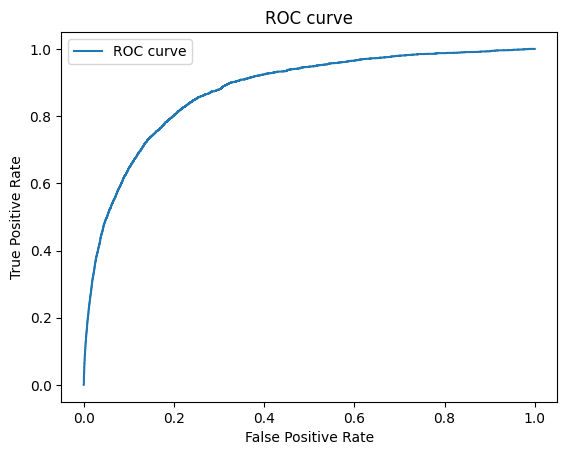

AUC: 0.8778659233740538
TPR:  49.69% 
FPR:  4.99% 
Threshold:  0.76
              precision    recall  f1-score   support

           0       1.00      0.83      0.91    202133
           1       0.06      0.76      0.11      2878

    accuracy                           0.83    205011
   macro avg       0.53      0.80      0.51    205011
weighted avg       0.98      0.83      0.90    205011



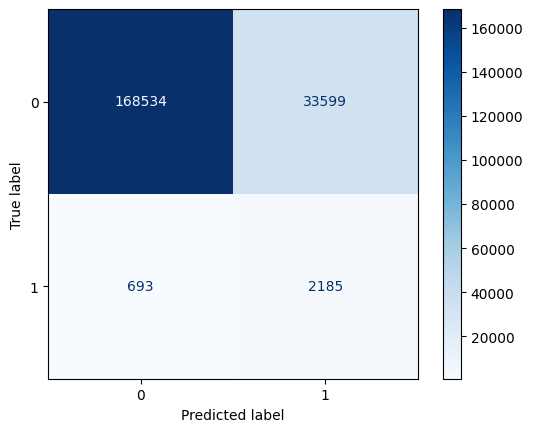

In [87]:
baseline_model = LogisticRegression(random_state=42, class_weight='balanced')
# baseline_model = RandomForestClassifier(random_state=42, class_weight='balanced')

baseline_model.fit(X_train, y_train)

baseline_y_pred = baseline_model.predict(X_test)

# baseline_f1 = f1_score(y_test, baseline_y_pred)
predictions = baseline_model.predict_proba(X_test)[:, 1]

fpr, tpr, _ = roc_curve(y_test, predictions)

target_fpr = 0.05
baseline_recall_at_fpr = 0.0

if np.any(fpr <= target_fpr):
    valid_indices = np.where(fpr <= target_fpr)[0] #where returns a tuple
    best_index = valid_indices[np.argmax(tpr[valid_indices])]
    baseline_tpr_at_fpr = tpr[best_index]

print(f"TPR: {baseline_tpr_at_fpr}")

evaluate(predictions)

print(classification_report(y_test, baseline_y_pred))
cm_baseline = confusion_matrix(y_test, baseline_y_pred)
disp_baseline = ConfusionMatrixDisplay(confusion_matrix=cm_baseline, display_labels=baseline_model.classes_)
disp_baseline.plot(cmap=plt.cm.Blues)
plt.show()

In [88]:
class Value(ABC):
    def evaluate(self):
        pass

class Scalar(ABC):
    pass

class Vectorial(ABC):
    pass

In [89]:
@dataclass
class PastValues(Vectorial):
    index: Annotated[int, IntRange(0, n_features-1)]
    lookback: Annotated[int, IntRange(5, 15)]

    # def evaluate(self, X_np, i):
    #     start_index = max(0, i-self.lookback+1)
    #     values = X_np[start_index: i+1, self.index]
    #     if len(values) < self.lookback: #if there are not enough past values
    #         padding = np.zeros(self.lookback - len(values))
    #         values = np.concatenate((padding, values))
    #     return values

    def evaluate(self, X_np):
        feature_col = X_np[:, self.index]
        padded_col = np.concatenate([np.zeros(self.lookback-1), feature_col])

        shape = (feature_col.shape[0], self.lookback)
        strides = (padded_col.strides[0], padded_col.strides[0])
        rolling_windows = as_strided(padded_col, shape=shape, strides=strides)

        return rolling_windows
    
    def __str__(self):
        return f"past_values({feature_names[self.index]}, {self.lookback})"

In [101]:
@dataclass
class Mean(Scalar):
    arr: Vectorial
    def evaluate(self, X_np):
        v = self.arr.evaluate(X_np)
        return np.mean(v)
    def __str__(self):
        return f"mean({self.arr})"
    
@dataclass
class Max(Scalar):
    arr: Vectorial
    def evaluate(self, X_np):
        v = self.arr.evaluate(X_np)
        return np.max(v)
    def __str__(self):
        return f"max({self.arr})"
    
@dataclass
class Min(Scalar):
    arr: Vectorial
    def evaluate(self, X_np):
        v = self.arr.evaluate(X_np)
        return np.min(v)
    def __str__(self):
        return f"min({self.arr})"
    
@dataclass
class Std(Scalar):
    arr: Vectorial
    def evaluate(self, X_np):
        v = self.arr.evaluate(X_np)
        return np.std(v)
    def __str__(self):
        return f"std({self.arr})"

In [102]:
@dataclass #Scalar Features (1)
class ScalarVar(Scalar): 
    index: Annotated[int, IntRange(0,n_features-1)]

    def evaluate(self, X_np):
        return X_np[:, self.index]
    
    def __str__(self):
        return feature_names[self.index]

# @dataclass #Vectorial Features ([1,2,3,4])
# class VectorialVar(Vectorial):
#     index: Annotated[int, IntRange(1,2)]
    
#     def evaluate(self, X):
#         return X[self.index]

In [103]:
#scalar -> scalar
@dataclass 
class Add(Scalar):
    right: Scalar
    left: Scalar

    def evaluate(self, X_np):
        return self.left.evaluate(X_np) + self.right.evaluate(X_np)
    
    def __str__(self):
        return f"({self.left} + {self.right})"

@dataclass
class Subtract(Scalar):
    right: Scalar
    left: Scalar

    def evaluate(self, X_np):
        return (self.left.evaluate(X_np)) - (self.right.evaluate(X_np))
    
    def __str__(self):
        return f"({self.left} - {self.right})"
    
@dataclass
class Multiply(Scalar):
    right: Scalar
    left: Scalar

    def evaluate(self, X_np):
        return self.left.evaluate(X_np) * self.right.evaluate(X_np)
    
    def __str__(self):
        return f"({self.left} * {self.right})"
    
@dataclass
class SafeDiv(Scalar):
    right: Scalar
    left: Scalar

    def evaluate(self, X_np):
        right_val = self.right.evaluate(X_np)
        if right_val==0:
            return 0.0
        left_val = self.left.evaluate(X_np)
        return left_val/right_val
    
    def __str__(self):
        return f"SafeDiv({self.left}/{self.right})"

In [104]:
grammar = extract_grammar([PastValues, Mean, Max, Min, Std, ScalarVar, Add, Subtract, Multiply], Scalar)
# grammar = extract_grammar([Add, Subtract, Multiply, ScalarVar], Scalar)
print(f"Grammar: {repr(grammar)}")

Grammar: Grammar<Starting=Scalar,Productions={
Scalar -> Mean(arr: Vectorial)|
	Max(arr: Vectorial)|
	Min(arr: Vectorial)|
	Std(arr: Vectorial)|
	ScalarVar(index: Annotated[int])|
	Add(right: Scalar, left: Scalar)|
	Subtract(right: Scalar, left: Scalar)|
	Multiply(right: Scalar, left: Scalar)

Vectorial -> PastValues(index: Annotated[int], lookback: Annotated[int])
}


In [105]:
X_train_np = X_train.to_numpy()
X_test_np = X_test.to_numpy()

def fitness_function(individual: Value): #individual -> expression
    # start = time.perf_counter()

    # train_feature = [individual.evaluate(X_train_np, i) for i in range(len(X_train_np))]
    # test_feature = [individual.evaluate(X_test_np, i) for i in range(len(X_test_np))]

    train_feature = individual.evaluate(X_train_np)
    test_feature = individual.evaluate(X_test_np)

    if train_feature.ndim == 0:
        train_feature = np.full(X_train_np.shape[0], train_feature)
    if test_feature.ndim == 0:
        test_feature = np.full(X_test_np.shape[0], test_feature)

    X_train_augmented = np.c_[X_train_np, np.array(train_feature).reshape(-1,1)]
    X_test_augmented = np.c_[X_test_np, np.array(test_feature).reshape(-1,1)]

    model = LogisticRegression(random_state=42, class_weight='balanced')
    model.fit(X_train_augmented, y_train)

    y_probs = model.predict_proba(X_test_augmented)[:, 1]

    fpr, tpr, thresholds = roc_curve(y_test, y_probs)

    target_fpr = 0.05
    recall_at_fpr = 0.0

    if np.any(fpr <= target_fpr):
        valid_indices = np.where(fpr<=target_fpr)[0]
        best_indice = valid_indices[np.argmax(tpr[valid_indices])]
        tpr_at_fpr = tpr[best_indice]

    roc_auc = roc_auc_score(y_test, y_probs)

    # tpr_diff = tpr_at_fpr-baseline_recall_at_fpr

    features, num_operations = analyse_complexity(individual)

    num_features = len(features)

    if num_operations == 0:
        num_operations = 1

    # elapsed = time.perf_counter() - start

    return [float(tpr_at_fpr), float(roc_auc), num_operations]

def analyse_complexity(individual: Value):
    if isinstance(individual, ScalarVar):
        return {individual.index}, 0 #unique feature
    if isinstance(individual, PastValues): 
        return {individual.index}, 0
    
    total_features = set()
    total_operations = 1
    if hasattr(individual, 'left') and hasattr(individual, 'right'):
        left_features, left_operations = analyse_complexity(individual.left)
        right_features, right_operations = analyse_complexity(individual.right)
        total_features.update(left_features)
        total_features.update(right_features)
        total_operations += left_operations + right_operations
    elif hasattr(individual, 'arr'):
        # if isinstance(individual, Mean) and isinstance(individual.arr, PastValues):
            # total_operations += individual.arr.lookback
        arr_features, arr_operations = analyse_complexity(individual.arr)
        total_features.update(arr_features)
        total_operations += arr_operations
    return total_features, total_operations


In [106]:
def lexicase_step():
    return ParallelStep(
        [
            # ElitismStep(),
            # NoveltyStep(),
            SequenceStep(
                LexicaseSelection(True),
                # TournamentSelection(5),
                GenericCrossoverStep(0.9),
                GenericMutationStep(0.1),
            ),
        ],
        # weights=[.1,.1,.8]
        # weights=[.9]
    )
prob = MultiObjectiveProblem(
    fitness_function=fitness_function,
    # minimize=[False, True, True, True],
    # minimize=[False, True, True],
    minimize=[False, False, True],
    # minimize=[False],
)
r = NativeRandomSource(123)
alg = GeneticProgramming(
    problem=prob,
    budget=TimeBudget(600),
    population_size=50,
    representation=TreeBasedRepresentation(grammar, MaxDepthDecider(r, grammar, 4)),
    # representation=StructuredGrammaticalEvolutionRepresentation(grammar, FullDecider(r, grammar, 4)),
    random=r,
    # population_initializer=FullInitializer(max_depth=3),
    step=lexicase_step(),
    tracker=ProgressTracker(
        prob,
        recorders=[CSVSearchRecorder(
            csv_path='feedzai_output.csv', 
            problem=prob, 
            fields={
                    # "Eval Time": lambda t,i,p: i.get_fitness(p).fitness_components[1],
                    "TPR": lambda t,i,p: i.get_fitness(p).fitness_components[0],
                    'AUC': lambda t,i,p: i.get_fitness(p).fitness_components[1],
                    'TPR Baseline Difference': lambda t,i,p: i.get_fitness(p).fitness_components[0] - baseline_tpr_at_fpr,
                    "Expression": lambda t, i, p: i.get_phenotype(),
                    'Num Operations': lambda t,i,p: i.get_fitness(p).fitness_components[2]
                    },
            only_record_best_individuals=False)]
    )
    
)

solutions = alg.search()

c:\Users\Gabriel\Desktop\Tese\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


KeyboardInterrupt: 

In [ ]:
sorted_solutions = sorted(solutions, key=lambda ind: ind.get_fitness(prob).fitness_components[0], reverse=True)

unique_solutions = []
seen_expressions = set()
for s in sorted_solutions:
    expr = str(s.get_phenotype())
    if expr not in seen_expressions:
        unique_solutions.append(s)
        seen_expressions.add(expr)

In [ ]:
for i,s in enumerate(unique_solutions[:10]):
    print(f"Solution {i}:")
    print(f"Expression: {s.get_phenotype()}")
    print(f"Fitness: {s.get_fitness(prob).fitness_components}\n")

Solution 0:
Expression: (max(past_values(current_address_months_count, 6)) - (mean(past_values(zip_count_4w, 7)) * (velocity_4w + date_of_birth_distinct_emails_4w)))
Fitness: [0.5006949270326616, 0.8779982319005609, 5]

Solution 1:
Expression: min(past_values(income, 12))
Fitness: [0.49722029186935374, 0.8778963906572954, 1]

Solution 2:
Expression: max(past_values(velocity_24h, 14))
Fitness: [0.49722029186935374, 0.8778936144971486, 1]

Solution 3:
Expression: (max(past_values(velocity_4w, 6)) * ((phone_home_valid + employment_status_CF) - mean(past_values(payment_type_AD, 14))))
Fitness: [0.49722029186935374, 0.8778465315086594, 5]

Solution 4:
Expression: (((intended_balcon_amount - zip_count_4w) - housing_status_BA) + max(past_values(device_os_macintosh, 12)))
Fitness: [0.49722029186935374, 0.8778927103112435, 4]

Solution 5:
Expression: max(past_values(velocity_24h, 6))
Fitness: [0.49722029186935374, 0.8778936144971486, 1]

Solution 6:
Expression: employment_status_CA
Fitness: [0.

In [ ]:
top_n_solutions = unique_solutions[:10]

In [ ]:
X_train_np = X_train.to_numpy()
X_test_np = X_test.to_numpy()
X_train_fe = X_train.copy()
X_test_fe = X_test.copy()
for i, target in enumerate(top_n_solutions):
    expression = target.get_phenotype()
    # train_feature_values = [expression.evaluate(X_train_np, i) for i in range(len(X_train_np))]
    # test_features_values = [expression.evaluate(X_test_np, i) for i in range(len(X_test_np))]

    train_features_values = expression.evaluate(X_train_np)
    test_features_values = expression.evaluate(X_test_np)

    
    X_train_fe[f'new_feature_{i}'] = train_features_values
    X_test_fe[f'new_feature_{i}'] = test_features_values

In [ ]:
X_train_fe.head(5)

,income,name_email_similarity,prev_address_months_count,current_address_months_count,customer_age,days_since_request,intended_balcon_amount,zip_count_4w,velocity_6h,velocity_24h,...,new_feature_0,new_feature_1,new_feature_2,new_feature_3,new_feature_4,new_feature_5,new_feature_6,new_feature_7,new_feature_8,new_feature_9
0,-0.847913,1.676177,-0.395497,-0.702018,0.523928,-0.196880,4.578476,-0.600874,2.305362,2.012562,...,3.747839,-1.5335,3.224175,-2.35964,6.179350,3.224175,0.0,-1.087732,1.73861,1.0
1,0.866055,0.407216,-0.395497,0.009959,-1.130108,-0.196255,-0.477577,-0.023033,1.020297,0.471870,...,3.747837,-1.5335,3.224175,2.70396,0.545456,3.224175,1.0,-1.087732,1.73861,0.0
2,0.866055,1.711249,-0.167211,-0.824389,0.523928,-0.195842,-0.508942,-0.566145,-0.556459,0.271930,...,3.747838,-1.5335,3.224175,-2.35964,1.057203,3.224175,1.0,-1.087732,1.73861,0.0
3,0.180468,-0.082125,-0.121554,-0.824389,-0.303090,-0.196833,-0.527184,1.737498,2.748663,1.210931,...,3.747838,-1.5335,3.224175,-2.35964,-1.264682,3.224175,1.0,-1.087732,1.73861,1.0
4,1.208849,1.180395,-0.395497,-0.657519,0.523928,0.869760,1.871825,0.633910,0.482157,0.017349,...,3.747839,-1.5335,3.224175,2.70396,2.237915,3.224175,1.0,-1.087732,1.73861,0.0


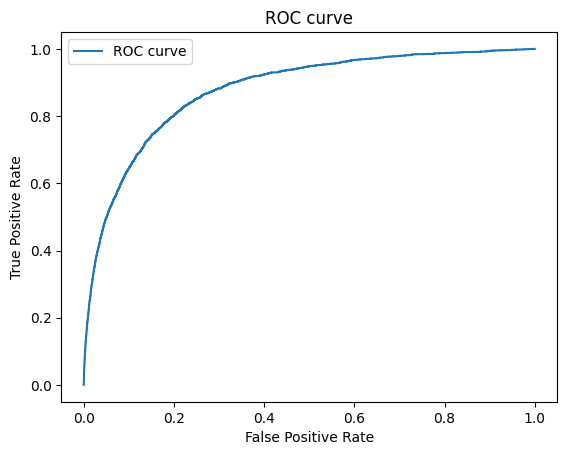

AUC: 0.878150590663568
TPR:  49.76% 
FPR:  5.0% 
Threshold:  0.78


In [ ]:
model_with_new_features = LogisticRegression(random_state=42, class_weight='balanced')
# model_with_new_features = RandomForestClassifier(random_state=42, class_weight='balanced')
model_with_new_features.fit(X_train_fe, y_train)

y_pred_with_new_features = model_with_new_features.predict(X_test_fe)

predictions_with_new_features = model_with_new_features.predict_proba(X_test_fe)[:, 1]

evaluate(predictions_with_new_features)

              precision    recall  f1-score   support

           0       1.00      0.82      0.90    202133
           1       0.06      0.78      0.11      2878

    accuracy                           0.82    205011
   macro avg       0.53      0.80      0.50    205011
weighted avg       0.98      0.82      0.89    205011



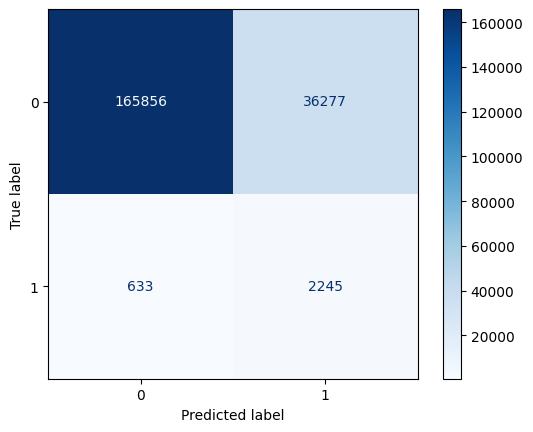

In [ ]:
print(classification_report(y_test, y_pred_with_new_features))
cm = confusion_matrix(y_test, y_pred_with_new_features)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model_with_new_features.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.show()

In [ ]:
temp_df = X_train_fe.copy()
temp_df['fraud_bool'] = y_train

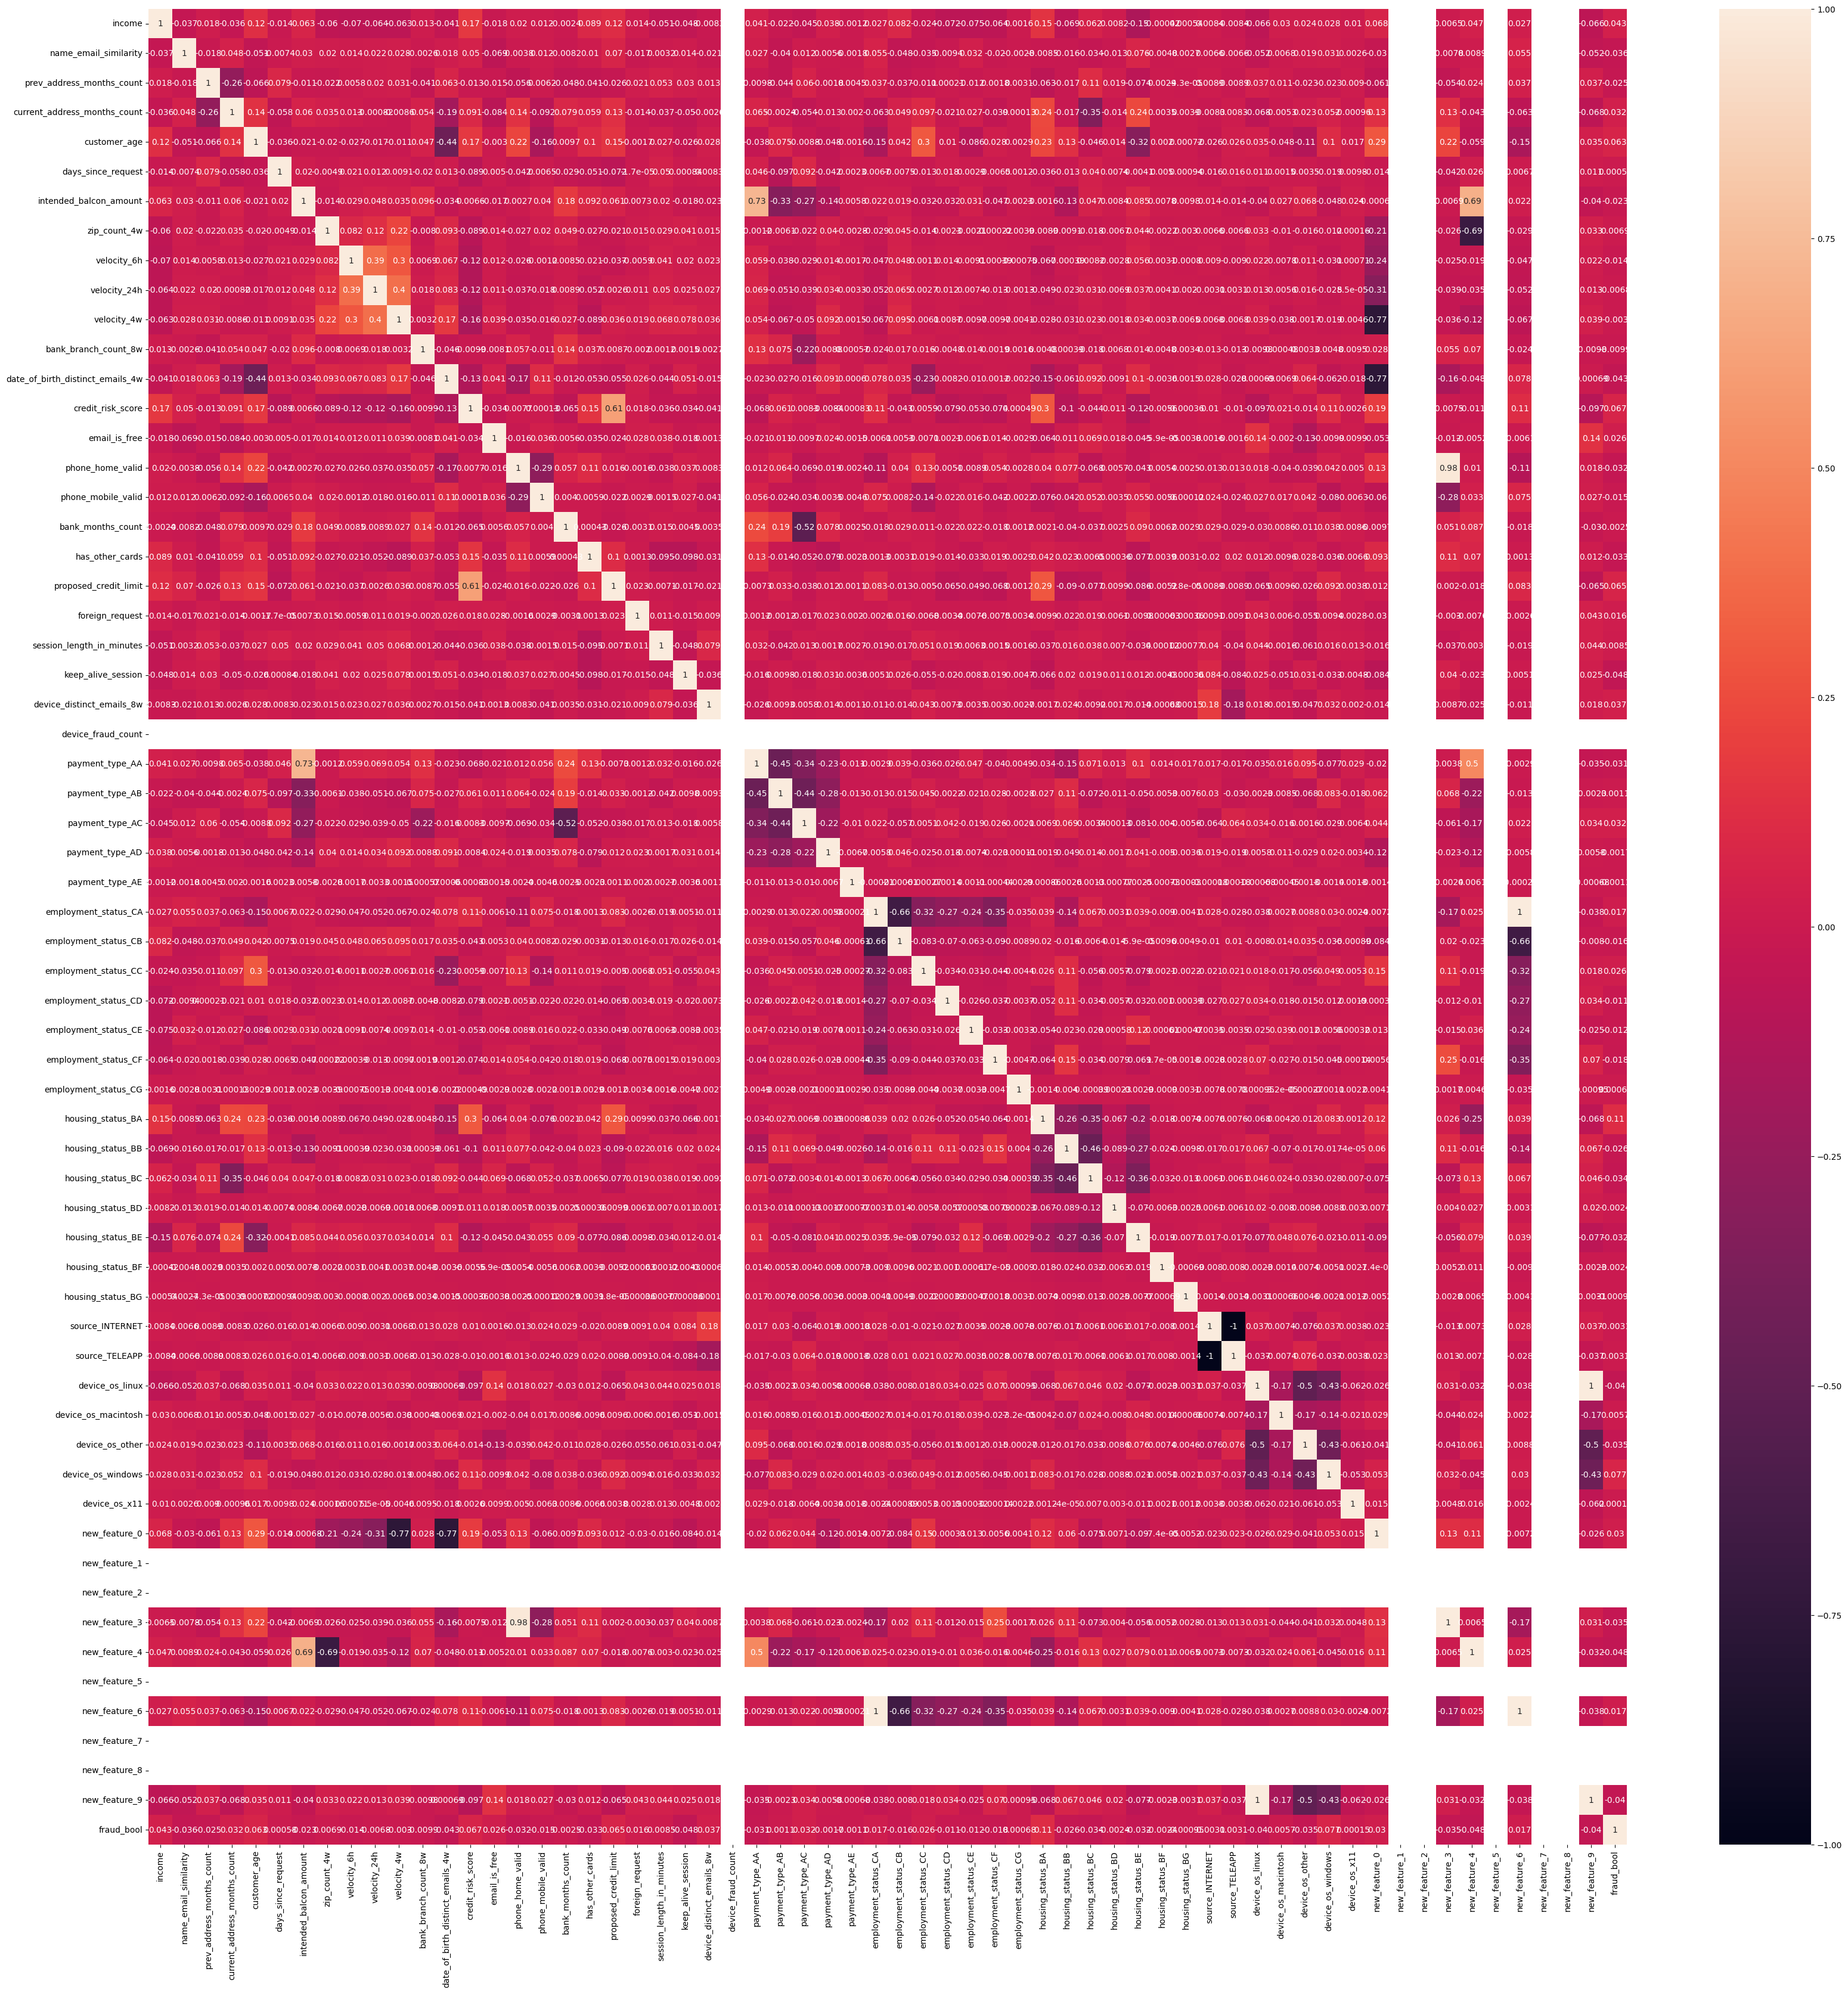

In [ ]:
correlation_matrix = temp_df.corr()
plt.figure(figsize=(40,40))
sns.heatmap(correlation_matrix, annot=True)
plt.show()

In [ ]:
# test = Max(arr=PastValues(index=feature_names.index('worst fractal dimension'), lookback=4))

# generated_value = [test.evaluate(X_test, i) for i in range(len(X_test))]

# test_df = X_test.copy()
# test_df['generated'] = generated_value
# test_df['target_x'] = y_test
# test_df.head(10)